# Análise Exploratória - Camada SILVER

## Mapa da Cidadania e Acesso à Informação no DF

---

### Arquitetura de Dados - Camada SILVER

**Contexto:**  
Esta análise opera sobre a **Camada SILVER** da arquitetura medalhão, onde os dados foram:

- **Tratados** a partir das fontes RAW de PDAD-A 2024, LAI/Participa DF e Projeções Populacionais
- **Padronizados** com colunas em `snake_case`, datas convertidas e códigos especiais da PDAD tratados
- **Agregados** respeitando a granularidade correta de cada fonte
- **Estruturados** para alimentar a camada Gold sem multiplicação artificial de linhas

### Objetivos da Análise

Este notebook valida e explora os principais produtos da Silver:

- Tabela consolidada territorial: `tb_mapa_cidadania_ra_ano_silver.csv`
- Tabela LAI por órgão e ano: `tb_lai_orgao_ano_silver.csv`
- Bases tratadas por fonte: PDAD, LAI e população

A tabela territorial principal possui granularidade:

```text
1 linha = 1 Região Administrativa + 1 ano
```

Como os arquivos LAI disponíveis não possuem Região Administrativa confiável, os indicadores de LAI são analisados separadamente por órgão e ano.

## 1. Configurações e Importações

In [1]:
# Bibliotecas de manipulação de dados
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações globais
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

# Caminhos
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'silver':
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == 'Data Layer':
    PROJECT_ROOT = PROJECT_ROOT.parent

SILVER_DIR = PROJECT_ROOT / 'Data Layer' / 'silver'

print(f'Projeto: {PROJECT_ROOT}')
print(f'Camada Silver: {SILVER_DIR}')

Projeto: /home/iggor/Documentos/Mapa-da-Cidadania-e-Acesso-a-Informacao-DF
Camada Silver: /home/iggor/Documentos/Mapa-da-Cidadania-e-Acesso-a-Informacao-DF/Data Layer/silver


## 2. Carregamento e Validação de Dados

### Contexto de Negócio

A **Camada SILVER** deste projeto não junta todos os dados linha a linha. As fontes possuem granularidades diferentes:

- PDAD moradores: 1 linha por morador
- PDAD domicílios: 1 linha por domicílio
- LAI pedidos: 1 linha por pedido
- LAI recursos: 1 linha por recurso
- LAI satisfação: 1 linha por avaliação
- População: 1 linha por Região Administrativa, sexo, faixa etária e ano

Por isso, a tabela principal usa indicadores agregados por **Região Administrativa + ano**, evitando duplicação artificial.

In [2]:
# Carregamento das tabelas Silver
mapa = pd.read_csv(SILVER_DIR / 'tb_mapa_cidadania_ra_ano_silver.csv')
populacao = pd.read_csv(SILVER_DIR / 'tb_populacao_ra_ano_silver.csv')
pdad_moradores = pd.read_csv(SILVER_DIR / 'tb_pdad_moradores_silver.csv', low_memory=False)
pdad_domicilios = pd.read_csv(SILVER_DIR / 'tb_pdad_domicilios_silver.csv', low_memory=False)
lai_pedidos = pd.read_csv(SILVER_DIR / 'tb_lai_pedidos_silver.csv', low_memory=False)
lai_recursos = pd.read_csv(SILVER_DIR / 'tb_lai_recursos_silver.csv', low_memory=False)
lai_satisfacao = pd.read_csv(SILVER_DIR / 'tb_lai_satisfacao_silver.csv', low_memory=False)

lai_orgao_path = SILVER_DIR / 'tb_lai_orgao_ano_silver.csv'
lai_orgao = pd.read_csv(lai_orgao_path) if lai_orgao_path.exists() else pd.DataFrame()

# Conversão de datas para análise
for df in [lai_pedidos, lai_recursos, lai_satisfacao]:
    for col in [c for c in df.columns if c.startswith('dt_') or '_dt_' in c or 'data' in c]:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print('RESUMO DOS DATASETS - CAMADA SILVER')
print(f"Tabela territorial: {mapa.shape[0]:,} linhas x {mapa.shape[1]} colunas")
print(f"Período territorial: {mapa['ano'].min()} a {mapa['ano'].max()}")
print(f"Regiões Administrativas: {mapa['regiao_administrativa'].nunique()}")
print(f"Pedidos LAI: {len(lai_pedidos):,}")
print(f"Recursos LAI: {len(lai_recursos):,}")
print(f"Avaliações de satisfação: {len(lai_satisfacao):,}")
print(f"Moradores PDAD tratados: {len(pdad_moradores):,}")
print(f"Domicílios PDAD tratados: {len(pdad_domicilios):,}")

display(mapa.head())

RESUMO DOS DATASETS - CAMADA SILVER
Tabela territorial: 99 linhas x 15 colunas
Período territorial: 2023 a 2025
Regiões Administrativas: 33
Pedidos LAI: 70,946
Recursos LAI: 3,998
Avaliações de satisfação: 7,369
Moradores PDAD tratados: 69,542
Domicílios PDAD tratados: 24,845


,ano,regiao_administrativa,populacao_total,populacao_masculina,populacao_feminina,populacao_0_14,populacao_15_59,populacao_60_mais,renda_media_ponderada,idade_media_ponderada,media_moradores_por_domicilio,percentual_baixa_escolaridade,percentual_domicilios_com_internet,percentual_domicilios_proprios,percentual_domicilios_alugados
0,2023,Arniqueira,47516.00,23191.00,24325.00,8875.00,33832.00,4809.00,733.10,34.73,2.72,31.11,96.19,63.25,30.46
1,2024,Arniqueira,47767.00,23319.00,24448.00,8695.00,34010.00,5062.00,733.10,34.73,2.72,31.11,96.19,63.25,30.46
2,2025,Arniqueira,47932.00,23407.00,24525.00,8525.00,34090.00,5317.00,733.10,34.73,2.72,31.11,96.19,63.25,30.46
3,2023,Brazlândia,65773.00,32287.00,33486.00,13959.00,44159.00,7655.00,765.10,33.46,2.85,36.09,89.47,58.15,28.32
4,2024,Brazlândia,66304.00,32521.00,33783.00,13871.00,44418.00,8015.00,765.10,33.46,2.85,36.09,89.47,58.15,28.32


### 2.1. Qualidade de Dados - Validação Silver

**Importância:**  
Na camada Silver, a qualidade dos dados é crítica porque ela alimenta a modelagem Gold e os indicadores finais do ITAC-DF.

**Verificações:**

- Granularidade única por Região Administrativa e ano
- Período restrito a 2023, 2024 e 2025
- Nulos por coluna
- Consistência de percentuais
- Separação entre LAI territorial e LAI por órgão

In [3]:
# Validação da granularidade RA/ano
duplicidades = mapa.duplicated(['regiao_administrativa', 'ano']).sum()
anos_disponiveis = sorted(mapa['ano'].dropna().unique())
ras_por_ano = mapa.groupby('ano')['regiao_administrativa'].nunique().reset_index(name='qtd_regioes_administrativas')

print('VALIDAÇÃO DA TABELA CONSOLIDADA')
print(f'Duplicidades em regiao_administrativa + ano: {duplicidades}')
print(f'Anos disponíveis: {anos_disponiveis}')
print(f'Total de nulos: {mapa.isna().sum().sum():,}')

display(ras_por_ano)
display(mapa.isna().sum().to_frame('nulos').query('nulos > 0'))

# Checagem de percentuais
cols_percentuais = [c for c in mapa.columns if c.startswith('percentual_')]
validacao_percentuais = pd.DataFrame({
    'coluna': cols_percentuais,
    'minimo': [mapa[c].min() for c in cols_percentuais],
    'maximo': [mapa[c].max() for c in cols_percentuais],
})
validacao_percentuais['dentro_0_100'] = validacao_percentuais['minimo'].ge(0) & validacao_percentuais['maximo'].le(100)
display(validacao_percentuais)

VALIDAÇÃO DA TABELA CONSOLIDADA
Duplicidades em regiao_administrativa + ano: 0
Anos disponíveis: [np.int64(2023), np.int64(2024), np.int64(2025)]
Total de nulos: 21


,ano,qtd_regioes_administrativas
0,2023,33
1,2024,33
2,2025,33


,nulos
renda_media_ponderada,3
idade_media_ponderada,3
media_moradores_por_domicilio,3
percentual_baixa_escolaridade,3
percentual_domicilios_com_internet,3
percentual_domicilios_proprios,3
percentual_domicilios_alugados,3


,coluna,minimo,maximo,dentro_0_100
0,percentual_baixa_escolaridade,15.56,44.26,True
1,percentual_domicilios_com_internet,81.89,100.00,True
2,percentual_domicilios_proprios,43.33,86.72,True
3,percentual_domicilios_alugados,6.27,44.08,True


## 3. Análise Populacional - Regiões Administrativas

### Insight de Negócio

A análise populacional por Região Administrativa permite identificar:

- Maiores concentrações populacionais do DF
- Evolução estimada entre 2023 e 2025
- Composição etária territorial
- Regiões com maior pressão potencial sobre serviços públicos

POPULAÇÃO TOTAL PROJETADA POR ANO


,ano,populacao_total
0,2023,3167502.00
1,2024,3204070.00
2,2025,3239675.00


MAIORES REGIÕES ADMINISTRATIVAS EM 2025


,regiao_administrativa,populacao_total,populacao_0_14,populacao_15_59,populacao_60_mais
11,Ceilândia,356548.00,65164.00,240551.00,50833.00
68,Samambaia,264403.00,55504.00,177833.00,31066.00
50,Plano Piloto,248568.00,30555.00,166760.00,51253.00
47,Planaltina,218569.00,44352.00,148733.00,25484.00
89,Taguatinga,217565.00,34013.00,140711.00,42841.00
53,Recanto das Emas,148474.00,29475.00,102364.00,16635.00
20,Gama,146705.00,22708.00,101118.00,22879.00
23,Guará,146001.00,24863.00,95923.00,25215.00
71,Santa Maria,132256.00,27082.00,88490.00,16684.00
98,Águas Claras,130342.00,28931.00,89898.00,11513.00


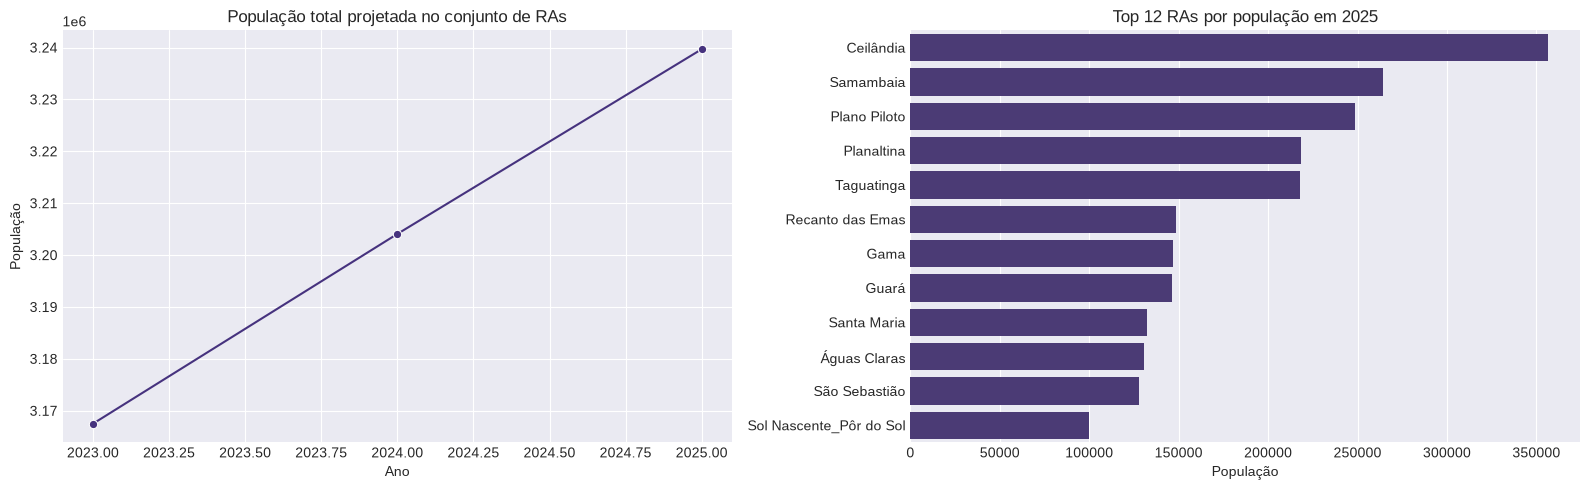

In [4]:
# População por ano e ranking de RAs
pop_ano = mapa.groupby('ano', as_index=False)['populacao_total'].sum()
pop_2025 = mapa[mapa['ano'] == 2025].sort_values('populacao_total', ascending=False).copy()

print('POPULAÇÃO TOTAL PROJETADA POR ANO')
display(pop_ano)

print('MAIORES REGIÕES ADMINISTRATIVAS EM 2025')
display(pop_2025[['regiao_administrativa', 'populacao_total', 'populacao_0_14', 'populacao_15_59', 'populacao_60_mais']].head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=pop_ano, x='ano', y='populacao_total', marker='o', ax=axes[0])
axes[0].set_title('População total projetada no conjunto de RAs')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('População')

sns.barplot(data=pop_2025.head(12), y='regiao_administrativa', x='populacao_total', ax=axes[1])
axes[1].set_title('Top 12 RAs por população em 2025')
axes[1].set_xlabel('População')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 3.1. Variação Populacional 2023 a 2025

**Análise Territorial:**

A variação populacional ajuda a localizar RAs com tendência de crescimento ou retração, informação útil para priorização territorial na camada Gold.

RAs COM MAIOR CRESCIMENTO RELATIVO


ano,regiao_administrativa,2023,2024,2025,variacao_abs_2023_2025,variacao_pct_2023_2025
8,Itapoã,83461.00,90667.00,97667.00,14206.00,17.02
25,Sobradinho II,79594.00,80006.00,84744.00,5150.00,6.47
17,Recanto das Emas,142331.00,145518.00,148474.00,6143.00,4.32
15,Planaltina,210578.00,214753.00,218569.00,7991.00,3.79
26,Sol Nascente_Pôr do Sol,96703.00,98447.00,99984.00,3281.00,3.39
9,Jardim Botânico,61261.00,62271.00,63186.00,1925.00,3.14
20,SCIA,38724.00,39342.00,39890.00,1166.00,3.01
22,Samambaia,257172.00,261025.00,264403.00,7231.00,2.81
16,Plano Piloto,242808.00,245902.00,248568.00,5760.00,2.37
31,Vicente Pires,80347.00,81256.00,82034.00,1687.00,2.10


RAs COM MAIOR REDUÇÃO RELATIVA


ano,regiao_administrativa,2023,2024,2025,variacao_abs_2023_2025,variacao_pct_2023_2025
2,Candangolândia,16216.00,16170.00,16094.00,-122.00,-0.75
4,Cruzeiro,30650.00,30568.00,30441.00,-209.00,-0.68
23,Santa Maria,132673.00,132582.00,132256.00,-417.00,-0.31
5,Fercal,9510.00,9517.00,9508.00,-2.00,-0.02
3,Ceilândia,355620.00,356361.00,356548.00,928.00,0.26
11,Lago Sul,30529.00,30610.00,30652.00,123.00,0.40
6,Gama,145723.00,146319.00,146705.00,982.00,0.67
13,Paranoá,76049.00,76426.00,76666.00,617.00,0.81
21,SIA,2669.00,2685.00,2692.00,23.00,0.86
0,Arniqueira,47516.00,47767.00,47932.00,416.00,0.88


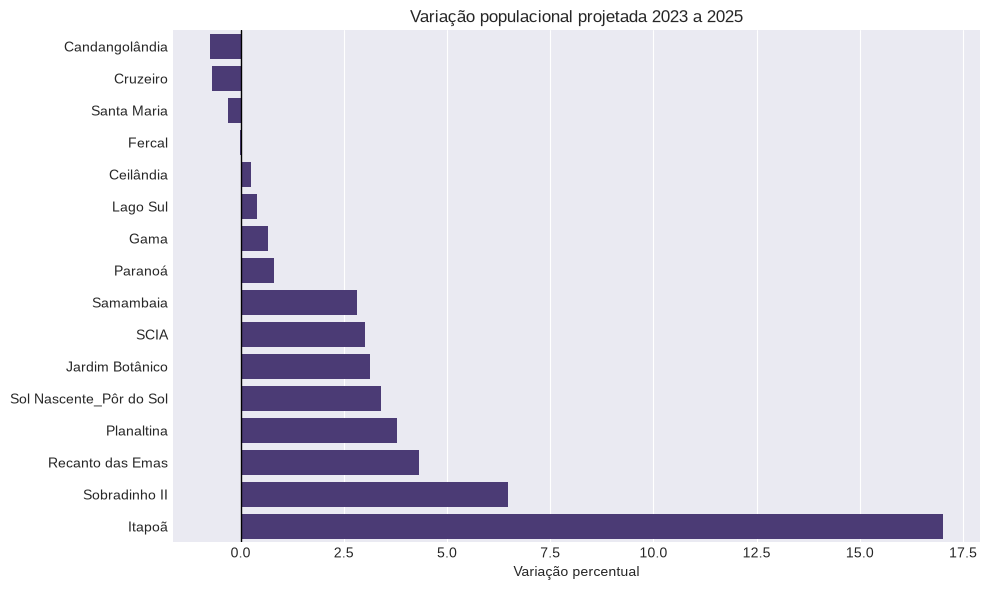

In [5]:
# Variação populacional entre 2023 e 2025
variacao_pop = mapa.pivot(index='regiao_administrativa', columns='ano', values='populacao_total').reset_index()
variacao_pop['variacao_abs_2023_2025'] = variacao_pop[2025] - variacao_pop[2023]
variacao_pop['variacao_pct_2023_2025'] = (variacao_pop[2025] / variacao_pop[2023] - 1) * 100

print('RAs COM MAIOR CRESCIMENTO RELATIVO')
display(variacao_pop.sort_values('variacao_pct_2023_2025', ascending=False).head(10))

print('RAs COM MAIOR REDUÇÃO RELATIVA')
display(variacao_pop.sort_values('variacao_pct_2023_2025').head(10))

plot_var = pd.concat([
    variacao_pop.nlargest(8, 'variacao_pct_2023_2025'),
    variacao_pop.nsmallest(8, 'variacao_pct_2023_2025'),
]).sort_values('variacao_pct_2023_2025')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_var, y='regiao_administrativa', x='variacao_pct_2023_2025')
plt.axvline(0, color='black', linewidth=1)
plt.title('Variação populacional projetada 2023 a 2025')
plt.xlabel('Variação percentual')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 4. Análise Socioeconômica - Perfil Territorial

### Indicadores Consolidados

A Silver integra indicadores ponderados da PDAD-A 2024 por Região Administrativa:

- Renda média ponderada
- Idade média ponderada
- Média de moradores por domicílio
- Baixa escolaridade
- Acesso domiciliar à internet
- Condição de ocupação do domicílio

Esses indicadores representam o perfil socioeconômico de referência para a tabela RA/ano.

MAIORES RENDAS MÉDIAS PONDERADAS


,regiao_administrativa,renda_media_ponderada,idade_media_ponderada,media_moradores_por_domicilio,percentual_baixa_escolaridade,percentual_domicilios_com_internet,percentual_domicilios_proprios,percentual_domicilios_alugados
34,Lago Sul,5255.80,44.63,3.03,15.56,99.75,86.72,10.53
49,Plano Piloto,3564.44,40.50,2.38,17.28,99.04,58.35,28.85
43,Park Way,3293.72,39.73,2.95,20.61,98.25,83.96,6.27
31,Lago Norte,2493.74,39.79,2.59,18.42,99.26,69.23,27.30
13,Cruzeiro,1867.63,39.51,2.39,17.42,96.99,52.88,30.33
22,Guará,1648.29,38.09,2.48,19.45,95.11,62.35,34.96
97,Águas Claras,1417.75,35.88,2.14,16.11,100.00,62.44,34.58
28,Jardim Botânico,1283.05,36.16,2.95,20.91,99.25,79.55,16.96
73,Sobradinho,1059.31,36.49,3.04,27.85,96.57,67.81,25.52
19,Gama,1051.43,36.08,2.88,29.39,93.25,64.25,28.75


MENORES RENDAS MÉDIAS PONDERADAS


,regiao_administrativa,renda_media_ponderada,idade_media_ponderada,media_moradores_por_domicilio,percentual_baixa_escolaridade,percentual_domicilios_com_internet,percentual_domicilios_proprios,percentual_domicilios_alugados
61,SCIA,247.74,27.59,3.02,44.26,81.89,75.29,18.41
64,SIA,269.20,30.82,2.99,31.66,94.00,43.33,34.00
16,Fercal,273.24,30.70,2.94,40.18,83.25,67.50,24.00
40,Paranoá,283.52,31.73,2.87,36.86,92.67,62.50,30.82
79,Sol Nascente_Pôr do Sol,308.17,29.47,2.97,40.26,88.22,68.92,23.56
91,Varjão,373.75,29.03,2.84,39.07,87.78,50.61,41.08
25,Itapoã,384.37,29.55,2.78,36.36,95.76,68.58,26.93
58,Riacho Fundo II,435.90,32.17,3.03,31.63,96.26,67.58,28.43
52,Recanto das Emas,439.23,32.02,2.99,37.38,88.05,62.61,29.42
70,Santa Maria,445.13,33.09,3.24,33.74,94.24,71.18,23.06


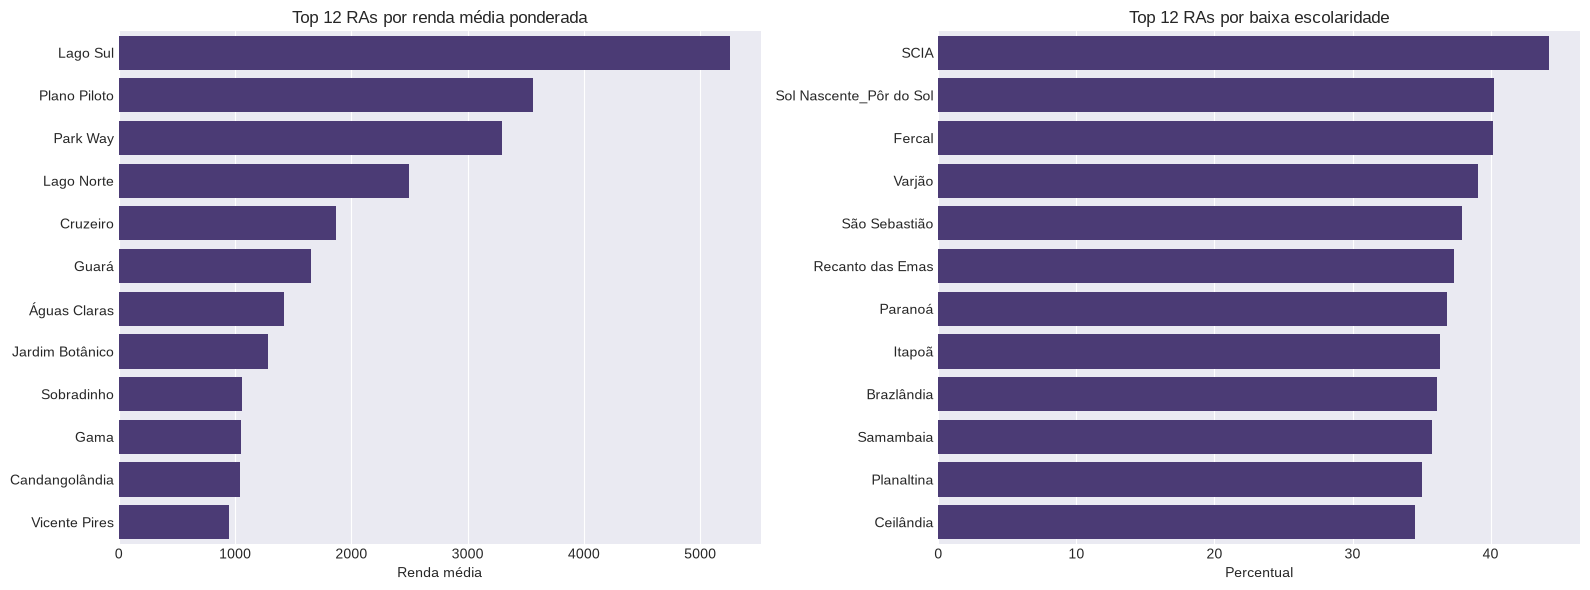

In [6]:
# Recorte socioeconômico de referência em 2024
socio_cols = [
    'regiao_administrativa',
    'renda_media_ponderada',
    'idade_media_ponderada',
    'media_moradores_por_domicilio',
    'percentual_baixa_escolaridade',
    'percentual_domicilios_com_internet',
    'percentual_domicilios_proprios',
    'percentual_domicilios_alugados',
]
socio = mapa[mapa['ano'] == 2024][socio_cols].copy()

print('MAIORES RENDAS MÉDIAS PONDERADAS')
display(socio.sort_values('renda_media_ponderada', ascending=False).head(10))

print('MENORES RENDAS MÉDIAS PONDERADAS')
display(socio.sort_values('renda_media_ponderada').head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=socio.sort_values('renda_media_ponderada', ascending=False).head(12), y='regiao_administrativa', x='renda_media_ponderada', ax=axes[0])
axes[0].set_title('Top 12 RAs por renda média ponderada')
axes[0].set_xlabel('Renda média')
axes[0].set_ylabel('')

sns.barplot(data=socio.sort_values('percentual_baixa_escolaridade', ascending=False).head(12), y='regiao_administrativa', x='percentual_baixa_escolaridade', ax=axes[1])
axes[1].set_title('Top 12 RAs por baixa escolaridade')
axes[1].set_xlabel('Percentual')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 4.1. Infraestrutura Domiciliar e Inclusão Digital

**Análise de Negócio:**

O acesso à internet e a condição do domicílio são variáveis relevantes para políticas de cidadania digital, acesso a serviços públicos e vulnerabilidade territorial.

RAs COM MENOR PERCENTUAL DE DOMICÍLIOS COM INTERNET


,regiao_administrativa,percentual_domicilios_com_internet,percentual_domicilios_proprios,percentual_domicilios_alugados
61,SCIA,81.89,75.29,18.41
16,Fercal,83.25,67.50,24.00
91,Varjão,87.78,50.61,41.08
52,Recanto das Emas,88.05,62.61,29.42
79,Sol Nascente_Pôr do Sol,88.22,68.92,23.56
4,Brazlândia,89.47,58.15,28.32
7,Candangolândia,91.07,55.09,41.94
67,Samambaia,91.14,61.84,31.83
85,São Sebastião,91.53,62.72,31.03
37,Núcleo Bandeirante,92.00,55.53,38.12


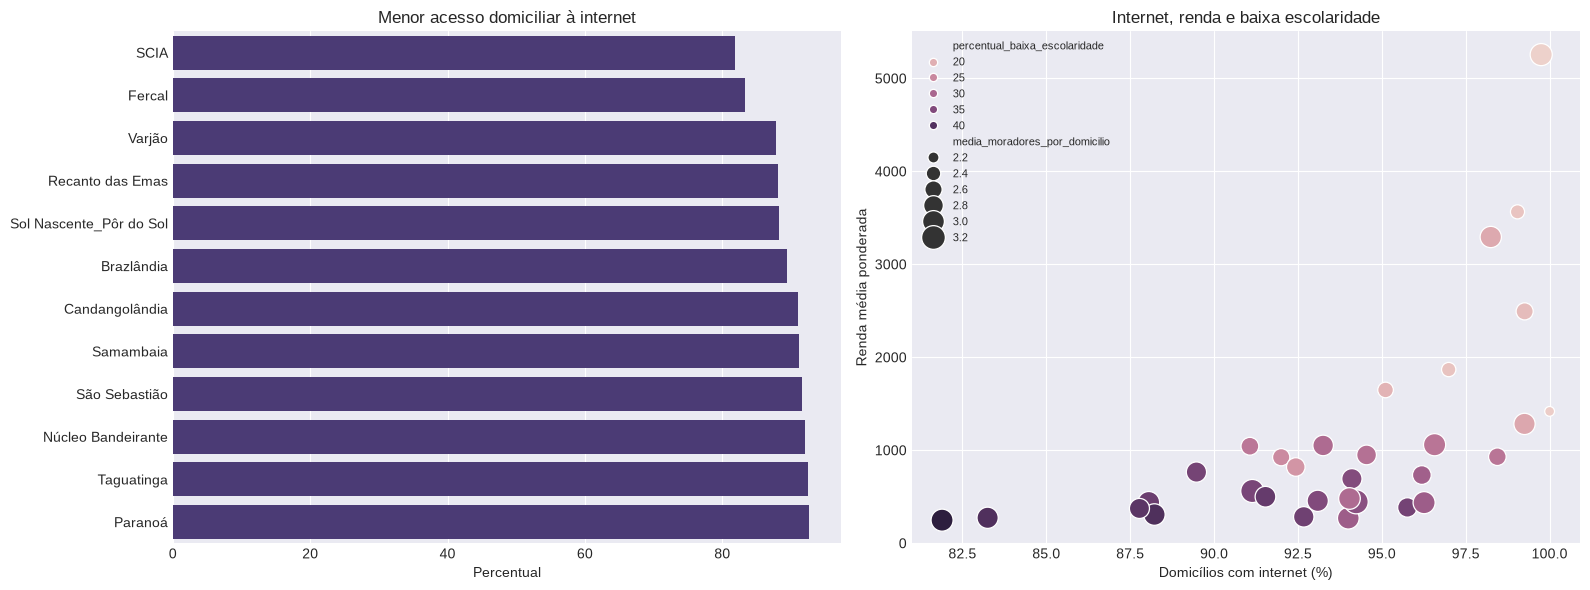

In [7]:
# Internet e condição domiciliar
infra = socio.sort_values('percentual_domicilios_com_internet', ascending=True).copy()

print('RAs COM MENOR PERCENTUAL DE DOMICÍLIOS COM INTERNET')
display(infra[['regiao_administrativa', 'percentual_domicilios_com_internet', 'percentual_domicilios_proprios', 'percentual_domicilios_alugados']].head(12))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=infra.head(12), y='regiao_administrativa', x='percentual_domicilios_com_internet', ax=axes[0])
axes[0].set_title('Menor acesso domiciliar à internet')
axes[0].set_xlabel('Percentual')
axes[0].set_ylabel('')

sns.scatterplot(
    data=socio,
    x='percentual_domicilios_com_internet',
    y='renda_media_ponderada',
    size='media_moradores_por_domicilio',
    hue='percentual_baixa_escolaridade',
    sizes=(50, 300),
    ax=axes[1],
)
axes[1].set_title('Internet, renda e baixa escolaridade')
axes[1].set_xlabel('Domicílios com internet (%)')
axes[1].set_ylabel('Renda média ponderada')
axes[1].legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Análise LAI - Pedidos, Respostas e Recursos

### Métricas Consolidadas

A LAI foi mantida em tabela própria por órgão e ano porque a base não possui Região Administrativa. Esta decisão preserva a qualidade da integração e evita atribuir pedidos a territórios sem evidência nos dados.

A análise permite observar:

- Volume de pedidos por ano
- Órgãos mais demandados
- Tempo médio de resposta
- Percentual de pedidos sem resposta
- Classificações de acesso concedido, negado e parcial
- Taxa de recurso por órgão

INDICADORES LAI POR ANO


,ano,qtd_pedidos_lai,tempo_medio_resposta_dias,percentual_sem_resposta,qtd_recursos_lai,qtd_satisfacoes_lai,taxa_recurso_lai
0,2023,20608,8.58,43.49,1317,2601,0.06
1,2024,23082,7.57,17.69,1388,2658,0.06
2,2025,27256,8.05,16.67,1293,2110,0.05


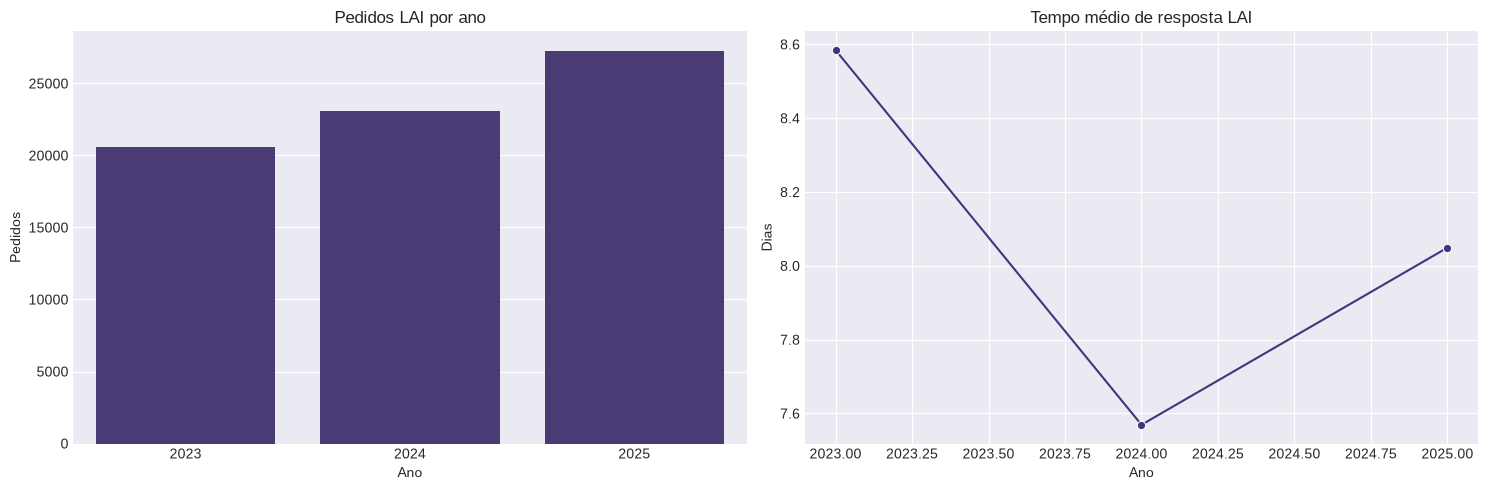

In [8]:
# Indicadores anuais da LAI
lai_anual = lai_pedidos.groupby('ano', as_index=False).agg(
    qtd_pedidos_lai=('nr_pedido_participa', 'nunique'),
    tempo_medio_resposta_dias=('dias_resposta', 'mean'),
    percentual_sem_resposta=('pedido_sem_resposta', lambda s: 100 * s.mean()),
)

recursos_anual = lai_recursos.groupby('ano', as_index=False).agg(
    qtd_recursos_lai=('nr_pedido_participa', 'count')
)

satisfacao_anual = lai_satisfacao.groupby('ano', as_index=False).agg(
    qtd_satisfacoes_lai=('nr_pedido_participa', 'count')
)

lai_anual = lai_anual.merge(recursos_anual, on='ano', how='left').merge(satisfacao_anual, on='ano', how='left')
lai_anual[['qtd_recursos_lai', 'qtd_satisfacoes_lai']] = lai_anual[['qtd_recursos_lai', 'qtd_satisfacoes_lai']].fillna(0)
lai_anual['taxa_recurso_lai'] = lai_anual['qtd_recursos_lai'] / lai_anual['qtd_pedidos_lai']

print('INDICADORES LAI POR ANO')
display(lai_anual)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=lai_anual, x='ano', y='qtd_pedidos_lai', ax=axes[0])
axes[0].set_title('Pedidos LAI por ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Pedidos')

sns.lineplot(data=lai_anual, x='ano', y='tempo_medio_resposta_dias', marker='o', ax=axes[1])
axes[1].set_title('Tempo médio de resposta LAI')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Dias')

plt.tight_layout()
plt.show()

### 5.1. Órgãos Mais Demandados

**Análise Operacional:**

O ranking por órgão ajuda a identificar onde a demanda por acesso à informação se concentra e quais unidades podem precisar de maior atenção na camada Gold.

ÓRGÃOS COM MAIS PEDIDOS LAI


,orgao,qtd_pedidos_lai,qtd_recursos_lai,tempo_medio_resposta_dias,percentual_sem_resposta,percentual_acesso_concedido,percentual_acesso_negado,taxa_recurso_lai
87,SES - Secretaria de Estado de Saúde do Distrit...,5717,386,6.86,17.94,50.66,11.00,0.07
48,DFLEGAL - Secretaria de Estado de Proteção da ...,4595,263,6.33,26.66,53.33,18.43,0.06
78,SEE - Secretaria de Estado de Educação do Dist...,4355,275,11.30,21.60,74.23,3.34,0.06
47,DETRAN - Departamento de Trânsito,4223,215,10.17,36.39,50.23,19.14,0.06
79,SEFAZ - Secretaria de Estado de Fazenda do Dis...,2440,123,5.27,22.59,40.97,5.15,0.05
86,"SEPLAD - Secretaria de Estado de Planejamento,...",2035,187,10.12,20.95,62.26,8.93,0.09
46,DER - Departamento de Estradas de Rodagem,1934,124,7.35,29.99,65.46,15.37,0.08
63,NOVACAP - Companhia Urbanizadora da Nova Capit...,1891,77,10.73,15.96,60.98,1.36,0.04
64,PCDF - Polícia Civil do Distrito Federal,1861,101,12.29,54.10,93.76,2.35,0.05
77,SEDUH - Secretaria de Estado de Desenvolviment...,1728,98,4.05,19.42,69.49,6.31,0.06


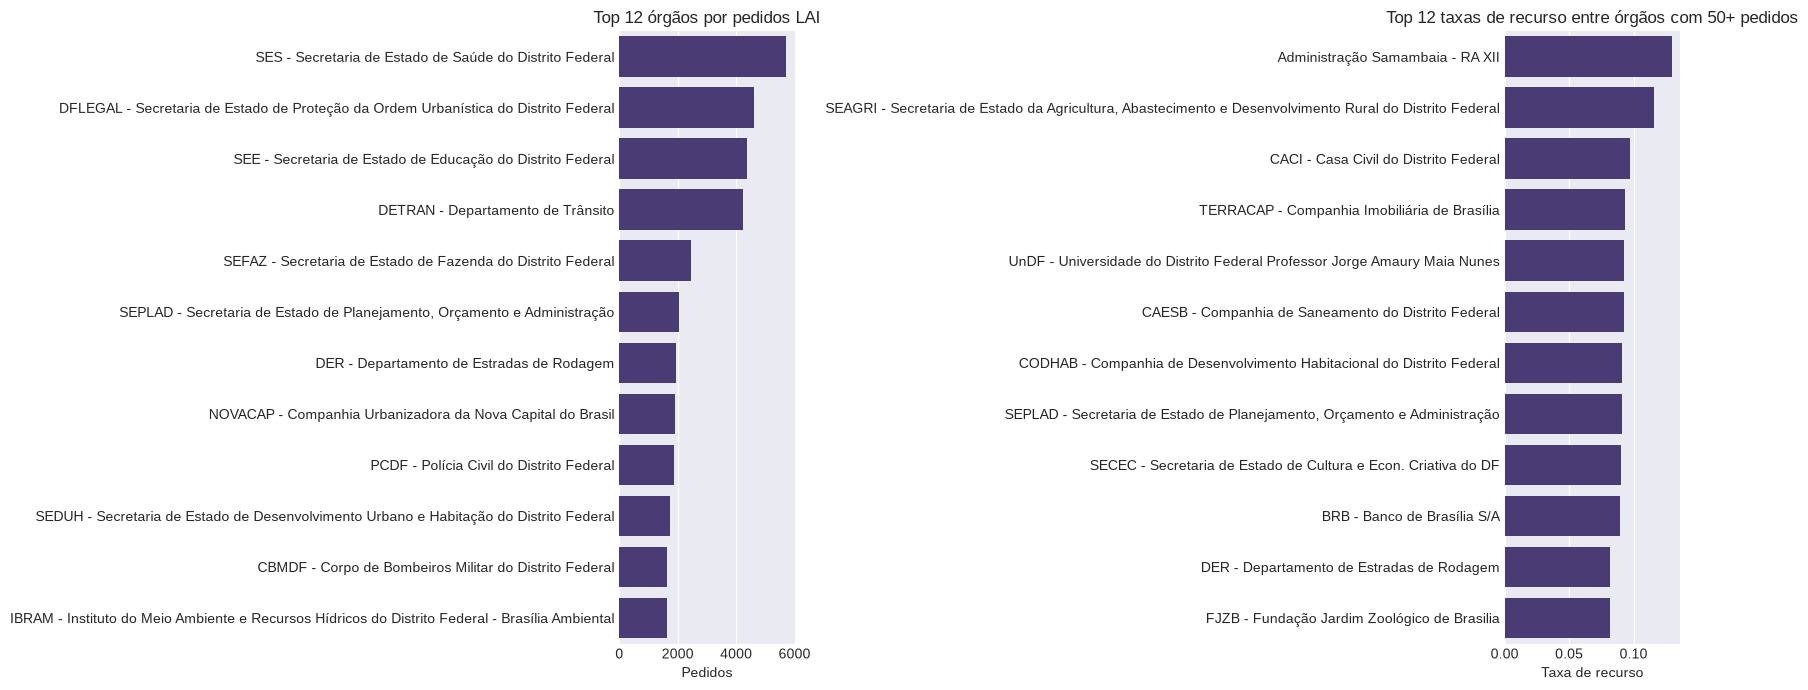

In [9]:
# Ranking de órgãos por volume de pedidos
if lai_orgao.empty:
    print('Tabela tb_lai_orgao_ano_silver.csv não encontrada.')
else:
    orgaos = lai_orgao.groupby('orgao', as_index=False).agg(
        qtd_pedidos_lai=('qtd_pedidos_lai', 'sum'),
        qtd_recursos_lai=('qtd_recursos_lai', 'sum'),
        tempo_medio_resposta_dias=('tempo_medio_resposta_dias', 'mean'),
        percentual_sem_resposta=('percentual_sem_resposta', 'mean'),
        percentual_acesso_concedido=('percentual_acesso_concedido', 'mean'),
        percentual_acesso_negado=('percentual_acesso_negado', 'mean'),
        taxa_recurso_lai=('taxa_recurso_lai', 'mean'),
    ).sort_values('qtd_pedidos_lai', ascending=False)

    print('ÓRGÃOS COM MAIS PEDIDOS LAI')
    display(orgaos.head(15))

    fig, axes = plt.subplots(1, 2, figsize=(17, 7))

    sns.barplot(data=orgaos.head(12), y='orgao', x='qtd_pedidos_lai', ax=axes[0])
    axes[0].set_title('Top 12 órgãos por pedidos LAI')
    axes[0].set_xlabel('Pedidos')
    axes[0].set_ylabel('')

    top_recursos = orgaos[orgaos['qtd_pedidos_lai'] >= 50].sort_values('taxa_recurso_lai', ascending=False).head(12)
    sns.barplot(data=top_recursos, y='orgao', x='taxa_recurso_lai', ax=axes[1])
    axes[1].set_title('Top 12 taxas de recurso entre órgãos com 50+ pedidos')
    axes[1].set_xlabel('Taxa de recurso')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

## 6. Relação entre Território e Perfil Socioeconômico

### Padrões Territoriais

Mesmo sem LAI territorial, a Silver já permite avaliar relações entre população, renda, escolaridade e infraestrutura domiciliar por RA. Essas relações são candidatas para compor dimensões e fatos na Gold.

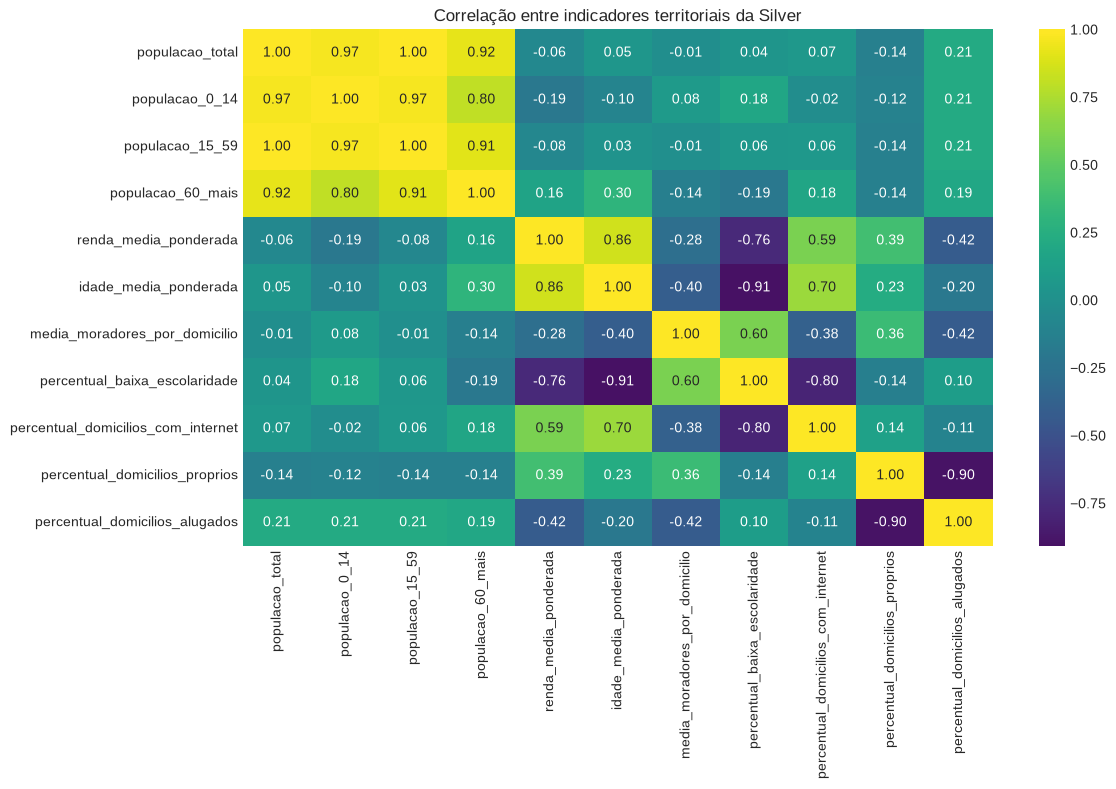

CORRELAÇÕES COM RENDA MÉDIA PONDERADA


,correlacao
renda_media_ponderada,1.00
idade_media_ponderada,0.86
percentual_domicilios_com_internet,0.59
percentual_domicilios_proprios,0.39
populacao_60_mais,0.16
populacao_total,-0.06
populacao_15_59,-0.08
populacao_0_14,-0.19
media_moradores_por_domicilio,-0.28
percentual_domicilios_alugados,-0.42


In [10]:
# Correlações entre indicadores territoriais
indicadores = [
    'populacao_total',
    'populacao_0_14',
    'populacao_15_59',
    'populacao_60_mais',
    'renda_media_ponderada',
    'idade_media_ponderada',
    'media_moradores_por_domicilio',
    'percentual_baixa_escolaridade',
    'percentual_domicilios_com_internet',
    'percentual_domicilios_proprios',
    'percentual_domicilios_alugados',
]
base_corr = mapa[mapa['ano'] == 2024][indicadores].copy()
corr = base_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis', center=0)
plt.title('Correlação entre indicadores territoriais da Silver')
plt.tight_layout()
plt.show()

print('CORRELAÇÕES COM RENDA MÉDIA PONDERADA')
display(corr['renda_media_ponderada'].sort_values(ascending=False).to_frame('correlacao'))

## 7. Síntese Estratégica - Insights para a Camada Gold

### Stakeholders

Os dados desta Silver podem apoiar análises para:

- Equipes de transparência e acesso à informação
- Planejamento territorial do DF
- Políticas de cidadania digital
- Priorização de serviços públicos por Região Administrativa
- Construção futura do ITAC-DF

In [11]:
# Consolidação de insights-chave
insights = {
    'Regiões Administrativas na tabela territorial': mapa['regiao_administrativa'].nunique(),
    'Anos analisados': mapa['ano'].nunique(),
    'Linhas na tabela territorial': len(mapa),
    'População total projetada em 2025': mapa.loc[mapa['ano'] == 2025, 'populacao_total'].sum(),
    'RA mais populosa em 2025': mapa.loc[mapa['ano'].eq(2025)].sort_values('populacao_total', ascending=False).iloc[0]['regiao_administrativa'],
    'Maior renda média ponderada': socio.sort_values('renda_media_ponderada', ascending=False).iloc[0]['regiao_administrativa'],
    'Menor acesso domiciliar à internet': socio.sort_values('percentual_domicilios_com_internet').iloc[0]['regiao_administrativa'],
    'Pedidos LAI analisados': len(lai_pedidos),
    'Recursos LAI analisados': len(lai_recursos),
    'Órgãos LAI analisados': lai_orgao['orgao'].nunique() if not lai_orgao.empty else 0,
}

resumo_insights = pd.DataFrame.from_dict(insights, orient='index', columns=['valor'])
display(resumo_insights)

print('LIMITAÇÕES REGISTRADAS')
print('- A LAI não foi integrada por Região Administrativa porque não há coluna territorial confiável nos arquivos RAW.')
print('- Indicadores da PDAD-A 2024 foram usados como perfil socioeconômico de referência para a tabela RA/ano.')
print('- A camada Silver preserva dados limpos e agregados; a modelagem dimensional deve ser feita na Gold.')

print()
print('PRÓXIMOS PASSOS PARA GOLD')
print('- Criar dim_regiao_administrativa e dim_tempo.')
print('- Criar fatos de população, perfil socioeconômico e LAI.')
print('- Construir o mart do ITAC-DF com regras explícitas de pontuação e normalização.')

,valor
Regiões Administrativas na tabela territorial,33
Anos analisados,3
Linhas na tabela territorial,99
População total projetada em 2025,3239675.00
RA mais populosa em 2025,Ceilândia
Maior renda média ponderada,Lago Sul
Menor acesso domiciliar à internet,SCIA
Pedidos LAI analisados,70946
Recursos LAI analisados,3998
Órgãos LAI analisados,97


LIMITAÇÕES REGISTRADAS
- A LAI não foi integrada por Região Administrativa porque não há coluna territorial confiável nos arquivos RAW.
- Indicadores da PDAD-A 2024 foram usados como perfil socioeconômico de referência para a tabela RA/ano.
- A camada Silver preserva dados limpos e agregados; a modelagem dimensional deve ser feita na Gold.

PRÓXIMOS PASSOS PARA GOLD
- Criar dim_regiao_administrativa e dim_tempo.
- Criar fatos de população, perfil socioeconômico e LAI.
- Construir o mart do ITAC-DF com regras explícitas de pontuação e normalização.
